# Transpilation

It is the process of rewriting an input circuit to match a quantum device for execution on quantum computers. It is known for its modularity (reduce complexity and add flexibility by breaking system and recombining) and extensibility (provide enhancements by adding functionality or modifying existing functionality). 

1. Construct a circuit that contains instructions.
2. Transform such that instructions available on a chosen backed are used.
3. Optimize the instructions to minimize effects of noise.

The transpiler is used to write new circuit transformations (transpiler passes) and combine them with other existing passes (reduces depth and complexity of quantum circuits). A key emphasis on which passes and in which order are they chained together. 

`PassManager` object - a collection of one or more passes

`StagedPassManager` object - executes one or more PassManagers and determines the order in which they are executed

The transpiler is designed to transform instructions in a given quantum circuit to obey the Instruction Set Architecture (ISA) of a given backend. Circuits obeying the ISA consist only of instructions that are supported by the backend's `Target` and comply with the constraints specified by the connectivity of the hardware (target's `CouplingMap`)

#### Transpiler Stages

This is the prebuilt transpiler pipeline and can be used as a guideline for customizing your own transpilation workflow. For a simpler, but less customizable way to use the transpiler - `qiskit.compiler.transpile` function. The `generate_preset_pass_manager` function creates a preset `StagedPassManager` object based on an optimization_level flag (0, 1, 2, 3). Higher levels generate more optimized circuits at the expense of longer transpilation times.


1. `init` - This pass runs any initial passes that are required before the circuit can be embedded.

This first stage is primarily useful for customizable initial optimizations. Because most layout and routing algorithms are only designed to work with single- and two-qubit gates, this stage is also used to translate any gates that operate on more than two qubits, into gates that only operate on one or two qubits.



2. `layout` - This pass maps the virtual qubits in the circuit to the Quantum Processing Unit's (QPU's) physical qubits.

The second stage involves the layout/connectivity of the backend a circuit will be sent to. In general, quantum circuits are abstract entities whose qubits are "virtual" or "logical" representations of actual qubits used in computations. To execute a sequence of gates, a one-to-one mapping from the "virtual" qubits to the "physical" qubits in an actual quantum device is necessary. This mapping is stored as a `Layout` object and is part of the constraints defined within a backend's ISA.

The choice of mapping is extremely important for minimizing the number of SWAP operations needed to map the input circuit onto the device topology and ensure the most well-calibrated qubits are used. Due to the importance of this stage, the preset pass managers try a few different methods to find the best layout. Typically this involves two steps: first, try to find a "perfect" layout (a layout that does not require any SWAP operations), and then, a heuristic pass that tries to find the best layout to use if a perfect layout cannot be found. 

There are two Passes typically used for this first step:

`TrivialLayout`: Naively maps each virtual qubit to the same numbered physical qubit on the device (i.e., [0,1,2,3] -> [0,1,2,3]). This is historical behavior only used in optimzation_level=1 to try to find a perfect layout. If it fails, VF2Layout is tried next.

`VF2Layout`: This is an AnalysisPass that selects an ideal layout by treating this stage as a subgraph isomorphism problem, solved by the VF2++ algorithm. If more than one layout is found, a scoring heuristic is run to select the mapping with the lowest average error.

Then for the heuristic stage, two passes are used by default:

`DenseLayout`: Finds the sub-graph of the device with the greatest connectivity and that has the same number of qubits as the circuit (used for optimization level 1 if there are control flow operations (such as IfElseOp) present in the circuit).

`SabreLayout`: This pass selects a layout by starting from an initial random layout and repeatedly running the SabreSwap algorithm. This pass is only used in optimization levels 1, 2, and 3 if a perfect layout isn't found via the VF2Layout pass.


Layout Selection (Placement)
* **SetLayout**	Set the layout property to the given layout.
* **TrivialLayout**	Choose a Layout by assigning n circuit qubits to device qubits 0, .., n-1.
* **DenseLayout**	Choose a Layout by finding the most connected subset of qubits.
* **SabreLayout**	Choose a Layout via iterative bidirectional routing of the input circuit.
* **CSPLayout**	If possible, chooses a Layout as a CSP, using backtracking.
* **VF2Layout**	A pass for choosing a Layout of a circuit onto a Coupling graph, as a subgraph isomorphism problem, solved by VF2++.
* **ApplyLayout**	Apply or update the mapping of virtual qubits to physical qubits in the DAGCircuit.
* **Layout2qDistance**	Evaluate how good the layout selection was.
* **EnlargeWithAncilla**	Extend the dag with virtual qubits that are in layout but not in the circuit yet.
* **FullAncillaAllocation**	Allocate all idle nodes from the coupling map or target as ancilla on the layout.
* **SabrePreLayout**	Choose a starting layout to use for additional Sabre layout trials.

3. `routing` - This pass runs after a layout has been applied and will inject gates in the original circuit to make it compatible with the QPU's connectivity i.e., the coupling map.

In order to implement a two-qubit gate between qubits that are not directly connected on a quantum device, one or more SWAP gates must be inserted into the circuit to move the qubit states around until they are adjacent on the device gate map. Each SWAP gate represents an expensive and noisy operation to perform. Thus, finding the minimum number of SWAP gates needed to map a circuit onto a given device is an important step in the transpilation process. For efficiency, this stage is typically computed alongside the Layout stage by default, but they are logically distinct from one another. The Layout stage selects the hardware qubits to be used, while the Routing stage inserts the appropriate amount of SWAP gates in order to execute the circuits using the selected layout.

However, finding the optimal SWAP mapping is hard. In fact, it is an NP-hard problem, and is thus prohibitively expensive to compute for all but the smallest quantum devices and input circuits. To work around this, Qiskit uses a stochastic heuristic algorithm called SabreSwap to compute a good, but not necessarily optimal, SWAP mapping. The use of a stochastic method means that the circuits generated are not guaranteed to be the same over repeated runs. Indeed, running the same circuit repeatedly results in a distribution of circuit depths and gate counts at the output. It is for this reason that many users choose to run the routing function (or the entire StagedPassManager) many times and select the lowest-depth circuits from the distribution of outputs.


Text(0, 0.5, 'Counts')

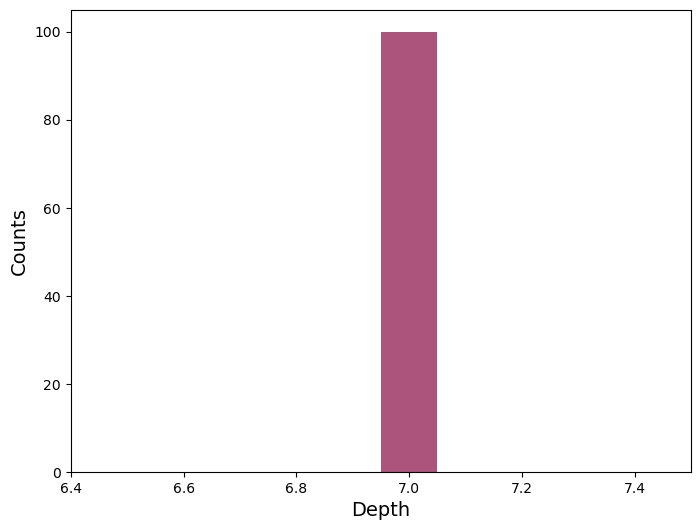

In [14]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.providers.fake_provider import GenericBackendV2

backend = GenericBackendV2(5)

ghz = QuantumCircuit(5)
ghz.h(0)
ghz.cx(0, range(1, 5))

depths = []
for seed in range(100):
    pass_manager = generate_preset_pass_manager(
        optimization_level=1,
        backend=backend,
        layout_method="trivial", 
        seed_transpiler=seed,  # For reproducible results
    )
    depths.append(pass_manager.run(ghz).depth())

plt.figure(figsize=(8, 6))
plt.hist(depths, align="left", color="#AC557C")
plt.xlabel("Depth", fontsize=14)
plt.ylabel("Counts", fontsize=14)

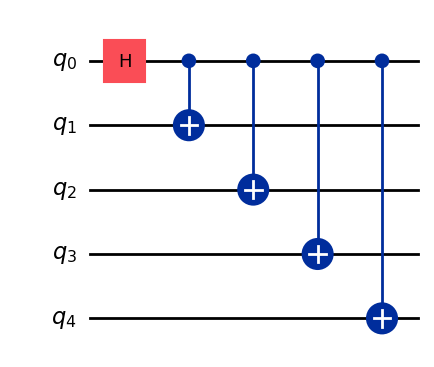

In [15]:
# This wide distribution demonstrates how difficult it is for the SWAP mapper to compute the best mapping. 
# To gain some insight, let's look at both the circuit being executed as well as the qubits that were chosen on the hardware.

ghz.draw("mpl", idle_wires=False)

Original GHZ circuit has 5 qubits with depth 5
Transpiled GHZ circuit has 5 qubits with depth 7


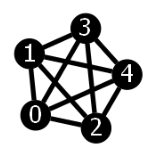

In [21]:
print(f"Original GHZ circuit has {ghz.num_qubits} qubits with depth {ghz.depth()}")
transpiled_circ = pass_manager.run(ghz)

print(f"Transpiled GHZ circuit has {transpiled_circ.num_qubits} qubits with depth {transpiled_circ.depth()}")

from qiskit.visualization import plot_circuit_layout
plot_circuit_layout(transpiled_circ, backend)

Routing

* **BasicSwap**	Map (with minimum effort) a DAGCircuit onto a coupling_map adding swap gates.
* **Commuting2qGateRouter**	A class to swap route one or more commuting gates to the coupling map.
* **LayoutTransformation**	Adds a Swap circuit for a given (partial) permutation to the circuit.
* **LookaheadSwap**	Map input circuit onto a backend topology via insertion of SWAPs.
* **SabreSwap**	Map input circuit onto a backend topology via insertion of SWAPs.
* **StarPreRouting**	Run star to linear pre-routing

4. `translation` - This pass translate the gates in the circuit to the QPU's basis set of instructions.

When writing a quantum circuit, you are free to use any quantum gate (unitary operation) that you like, along with a collection of non-gate operations such as qubit measurement or reset instructions. However, most quantum devices only natively support a handful of quantum gate and non-gate operations. These native gates are part of the definition of a target's ISA and this stage of the preset PassManagers translates (or unrolls) the gates specified in a circuit to the native basis gates of a specified backend. This is an important step, as it allows the circuit to be executed by the backend, but typically leads to an increase in the depth and number of gates.


native gates:['cx', 'delay', 'id', 'measure', 'reset', 'rz', 'sx', 'x']


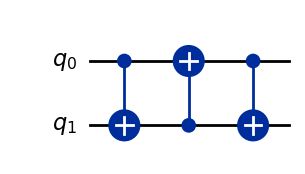

In [5]:
# If a SWAP gate is not a native gate to the target backend, this requires three CNOT gates:

print("native gates:" + str(sorted(backend.operation_names)))
qc = QuantumCircuit(2)
qc.swap(0, 1)
qc.decompose().draw("mpl")

As a product of three CNOT gates, a SWAP is an expensive operation to perform on noisy quantum devices. However, such operations are usually necessary for embedding a circuit into the limited gate connectivities of many devices. Thus, minimizing the number of SWAP gates in a circuit is a primary goal in the transpilation process.

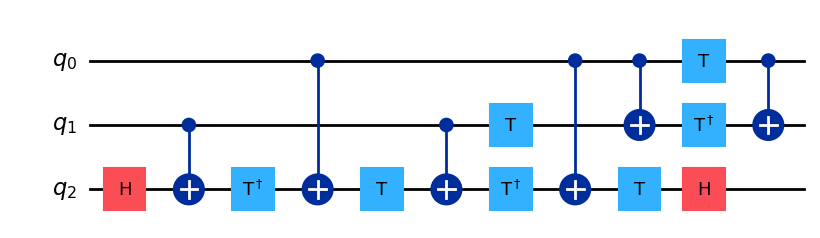

In [6]:
# A Toffoli, or controlled-controlled-not gate (ccx), is a three-qubit gate. 
# Given that our basis gate set includes only single- and two-qubit gates, this operation must be decomposed. 
# However, it is quite costly:

qc = QuantumCircuit(3)
qc.ccx(0, 1, 2)
qc.decompose().draw("mpl")

For every Toffoli gate in a quantum circuit, the hardware may execute up to six CNOT gates and a handful of single-qubit gates. This example demonstrates that any algorithm making use of multiple Toffoli gates will end up as a circuit with large depth and will therefore be appreciably affected by noise.

Basis Change

* **BasisTranslator**	Translates gates to a target basis by searching for a set of translations from a given EquivalenceLibrary.
* **Decompose**	Expand a gate in a circuit using its decomposition rules.
* **TranslateParameterizedGates**	Translate parameterized gates to a supported basis set.
* **Unroll3qOrMore** Recursively expands 3q+ gates until the circuit only contains 2q or 1q gates.
* **UnrollCustomDefinitions**	Unrolls instructions with custom definitions.

5. `optimization` - This pass runs an optimization loop to find more efficient decompositions of the quantum circuit until a condition is met.

This stage centers around decomposing quantum circuits into the basis gate set of the target device, and must fight against the increased depth from the layout and routing stages. Fortunately, there are many routines for optimizing circuits by either combining or eliminating gates. In some cases, these methods are so effective that the output circuits have lower depth than the inputs, even after layout and routing to the hardware topology. In other cases, not much can be done, and the computation may be difficult to perform on noisy devices. This stage is where the various optimization levels begin to differ.

- For optimization_level=1, this stage prepares `Optimize1qGatesDecomposition` and `CXCancellation`, which combine chains of single-qubit gates and cancel any back-to-back CNOT gates.
- For optimization_level=2, this stage uses the `CommutativeCancellation` pass instead of CXCancellation, which removes redundant gates by exploiting commutation relations.
- For optimization_level=3, this stage prepares the following passes:
`Collect2qBlocks` , `ConsolidateBlocks` , `UnitarySynthesis` , `Optimize1qGateDecomposition` , `CommutativeCancellation`

Additionally, this stage also executes a few final checks to make sure that all instructions in the circuit are composed of the basis gates available on the target backend.

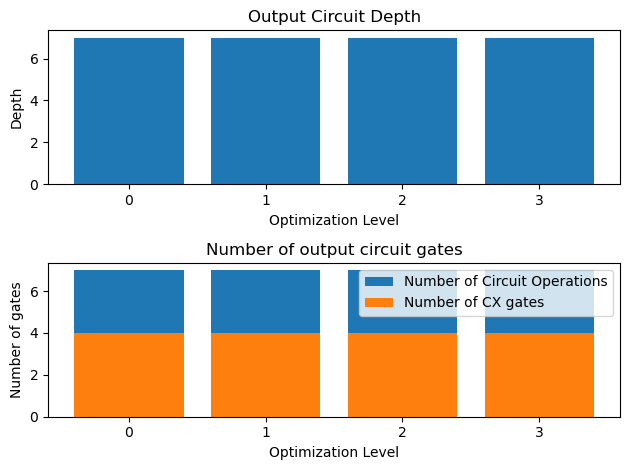

In [22]:
# The example below using a GHZ state demonstrates the effects of different optimization level settings on circuit depth and gate count.
# The transpilation output varies due to the stochastic SWAP mapper. Therefore, the numbers below will likely change each time you run the code.
# The following code compares the optimization_levels of transpilation in terms of resulting circuit depth, gate counts, and multi-qubit gate counts.

ghz = QuantumCircuit(5)
ghz.h(0)
ghz.cx(0, range(1, 5))

depths = []
gate_counts = []
multiqubit_gate_counts = []
levels = [str(x) for x in range(4)]
for level in range(4):
    pass_manager = generate_preset_pass_manager(
        optimization_level=level,
        backend=backend,
        seed_transpiler=1234,
    )
    circ = pass_manager.run(ghz)
    depths.append(circ.depth())
    gate_counts.append(sum(circ.count_ops().values()))
    multiqubit_gate_counts.append(circ.count_ops()["cx"])

fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.bar(levels, depths, label="Depth")
ax1.set_xlabel("Optimization Level")
ax1.set_ylabel("Depth")
ax1.set_title("Output Circuit Depth")
ax2.bar(levels, gate_counts, label="Number of Circuit Operations")
ax2.bar(levels, multiqubit_gate_counts, label="Number of CX gates")
ax2.set_xlabel("Optimization Level")
ax2.set_ylabel("Number of gates")
ax2.legend()
ax2.set_title("Number of output circuit gates")
fig.tight_layout()
plt.show()

Optimization

* **Collect1qRuns**	Collect one-qubit subcircuits.
* **Collect2qBlocks**	Collect two-qubit subcircuits.
* **CollectAndCollapse**	A general transpiler pass to collect and to consolidate blocks of nodes in a circuit.
* **CollectCliffords**	Collects blocks of Clifford gates and replaces them by a Clifford object.
* **CollectLinearFunctions**	Collect blocks of linear gates (CXGate and SwapGate gates) and replaces them by linear functions (LinearFunction).
* **CollectMultiQBlocks**	Collect sequences of uninterrupted gates acting on groups of qubits.
* **CommutationAnalysis**	Analysis pass to find commutation relations between DAG nodes.
* **CommutativeCancellation**	Cancel the redundant (self-adjoint) gates through commutation relations.
* **CommutativeInverseCancellation**	Cancel pairs of inverse gates exploiting commutation relations.
* **CommutativeOptimization**	Cancel/merge gates exploiting commutativity relations.
* **ConsolidateBlocks**	Replace each block of consecutive gates by a single Unitary node.
* **ContractIdleWiresInControlFlow**	Remove idle qubits from control-flow operations of a DAGCircuit.
* **ElidePermutations**	Remove permutation operations from a pre-layout circuit
* **HoareOptimizer**	This is a transpiler pass using Hoare logic circuit optimization.
* **InverseCancellation**	Cancel specific Gates which are inverses of each other when they occur back-to- back.
* **LightCone**	Remove the gates that do not affect the outcome of a measurement on a circuit.
* **LitinskiTransformation**	Applies Litinski transform to a circuit.
* **Optimize1qGates**	Optimize chains of single-qubit u1, u2, u3 gates by combining them into a single gate.
* **Optimize1qGatesDecomposition**	Optimize chains of single-qubit gates by combining them into a single gate.
* **Optimize1qGatesSimpleCommutation**	Optimizes 1Q gate strings interrupted by 2Q gates by commuting the components and resynthesizing the results.
* **OptimizeAnnotated**	Optimization pass on circuits with annotated operations.
* **OptimizeCliffordT**	An optimization pass for Clifford+T circuits.
* **OptimizeCliffords**	Combine consecutive Cliffords over the same qubits.
* **OptimizeSwapBeforeMeasure**	Remove the swaps followed by measurement (and adapt the measurement).
* **RemoveDiagonalGatesBeforeMeasure**	Remove diagonal gates (including diagonal 2Q gates) before a measurement.
* **RemoveFinalReset**	Remove reset when it is the final instruction on a qubit wire.
* **RemoveIdentityEquivalent**	Remove gates with negligible effects.
* **RemoveResetInZeroState** Remove reset gate when the qubit is in zero state.
* **ResetAfterMeasureSimplification**	This pass replaces reset after measure with a conditional X gate.
* **Split2QUnitaries**	Attempt to split two-qubit unitaries in a DAGCircuit into two single-qubit gates.
* **SubstitutePi4Rotations**	Convert single-qubit rotation gates RZGate, RXGate and RYGate, whose angles are integer multiples of π/4 into discrete sets of Clifford, TGate and TdgGate gates.
* **TemplateOptimization**	Class for the template optimization pass.

6. `scheduling` - This pass is for any hardware-aware scheduling passes.

This last stage is only run if it is explicitly called for (similar to the Init stage) and does not run by default (though a method can be specified by setting the scheduling_method argument when calling generate_preset_pass_manager). The scheduling stage is typically used once the circuit has been translated to the target basis, mapped to the device, and optimized. These passes focus on accounting for all the idle time in a circuit. At a high level, the scheduling pass can be thought of as explicitly inserting delay instructions to account for the idle time between gate executions and to inspect how long the circuit will be running on the backend.

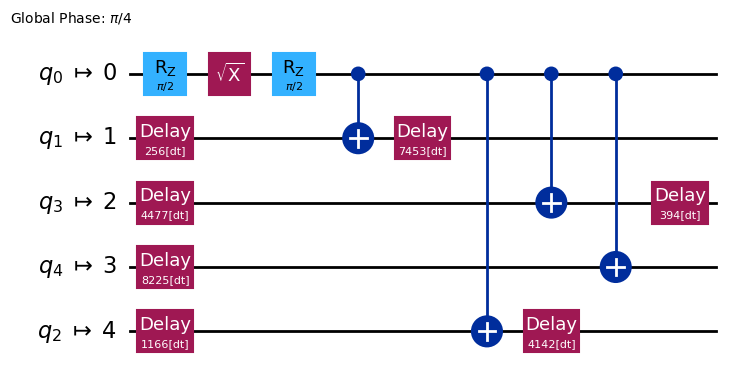

In [ ]:
ghz = QuantumCircuit(5)
ghz.h(0)
ghz.cx(0, range(1, 5))


# Use fake backend
backend = GenericBackendV2(5)

# Run with optimization level 3 and 'asap' scheduling pass
pass_manager = generate_preset_pass_manager(
    optimization_level=3,
    backend=backend,
    scheduling_method="asap",
    seed_transpiler=1234,
)

circ = pass_manager.run(ghz)
circ.draw(output="mpl", idle_wires=False)

Scheduling a circuit involves two parts: analysis and constraint mapping, followed by a padding pass. The first part requires running a scheduling analysis pass (by default this is ALAPSchedulingAnalysis), which analyzes the circuit and records the start time of each instruction in the circuit into a schedule. Once the circuit has an initial schedule, additional passes can be run to account for any timing constraints on the target backend. Finally, a padding pass such as PadDelay or PadDynamicalDecoupling can be executed.

Scheduling

* **ALAPScheduleAnalysis**	ALAP Scheduling pass, which schedules the stop time of instructions as late as possible.
* **ASAPScheduleAnalysis**	ASAP Scheduling pass, which schedules the start time of instructions as early as possible.
* **ConstrainedReschedule**	Rescheduler pass that updates node start times to conform to the hardware alignments.
* **ContextAwareDynamicalDecoupling**	Implement an X-sequence dynamical decoupling considering the gate- and qubit-context.
* **InstructionDurationCheck**	Duration validation pass for reschedule.
* **PadDelay**	Padding idle time with Delay instructions.
* **PadDynamicalDecoupling**	Dynamical decoupling insertion pass.
* **SetIOLatency**	Set IOLatency information to the input circuit.
* **TimeUnitConversion**	Choose a time unit to be used in the following time-aware passes, and make all circuit time units consistent with that.

# Transpile with pass managers


The recommended way to transpile a circuit is to create a staged pass manager and then execute its run method with your circuit as input. You can use the generate_preset_pass_manager function to generate a staged pass manager with reasonable defaults.

A pass manager is an object that stores a list of transpiler passes and can execute them on a circuit. Create a pass manager by initializing a PassManager with a list of transpiler passes. To run the transpilation on a circuit, call the run method with a circuit as input.

More advanced users can customize a set of PassManager and StagedPassManager objects and determine the order in which each stage is run. This can dramatically change the final output circuit. In fact, a custom approach to transpiling a quantum algorithm often produces more efficient error suppression than the default approach. A custom approach involves rewriting quantum circuits to match hardware constraints and suppress the effects of noise. The flow of logic for this tool chain is customizable and need not be linear. The transpilation process can prepare iterative loops, conditional branches, and other complex behaviors. A good starting place when developing a set of custom passes is to examine the default sequence of transformations.

A staged pass manager is a special kind of pass manager that represents a level of abstraction above that of a normal pass manager. While a normal pass manager is composed of several transpiler passes, a staged pass manager is composed of several pass managers. This is a useful abstraction because transpilation typically happens in discrete stages, as described in Transpiler stages, with each stage being represented by a pass manager. Staged pass managers are represented by the StagedPassManager class. 

In [13]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke 

backend = FakeSherbrooke()
pass_manager = generate_preset_pass_manager(
    optimization_level=3, backend=backend
)

c:\Users\nikhi\anaconda3\Lib\site-packages\samplomatic\__init__.py:20: UserWarning: 
You have imported samplomatic==0.17.1 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


To transpile a circuit or list of circuits with a pass manager, pass the circuit or list of circuits to the run method. Let's do this on a two-qubit circuit consisting of a Hadamard followed by two adjacent CX gates:

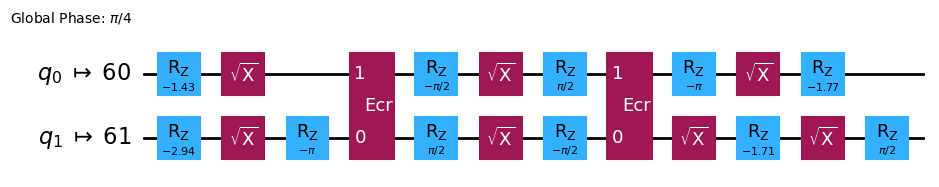

In [14]:
from qiskit import QuantumRegister, QuantumCircuit

# Create a circuit
qubits = QuantumRegister(2, name="q")
circuit = QuantumCircuit(qubits)
a, b = qubits
circuit.h(a)
circuit.cx(a, b)
circuit.cx(b, a)

# Transpile it by calling the run method of the pass manager
transpiled = pass_manager.run(circuit)

# Draw it, excluding idle qubits from the diagram
transpiled.draw("mpl", idle_wires=False)

In [ ]:
#Create a custom pass manager for unitary synthesis to the basis gates of the target backend

from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import (
    Collect2qBlocks,
    ConsolidateBlocks,
    UnitarySynthesis,
)

basis_gates = ["rx", "ry", "rxx"]
translate = PassManager(
    [
        Collect2qBlocks(),
        ConsolidateBlocks(basis_gates=basis_gates),
        UnitarySynthesis(basis_gates),
    ]
)

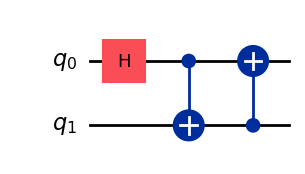

In [16]:
from qiskit import QuantumRegister, QuantumCircuit

qubits = QuantumRegister(2, name="q")
circuit = QuantumCircuit(qubits)

a, b = qubits
circuit.h(a)
circuit.cx(a, b)
circuit.cx(b, a)

circuit.draw("mpl")

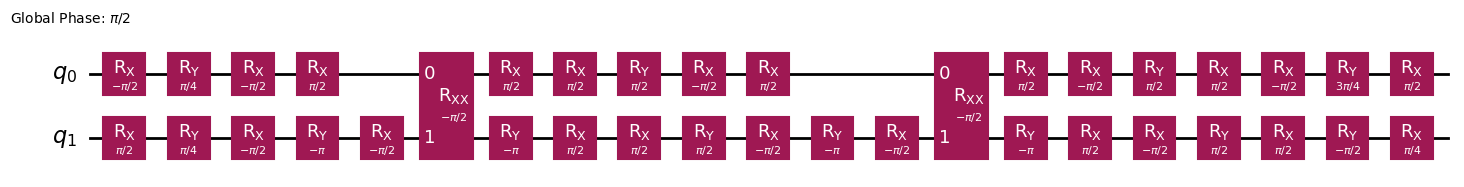

In [17]:
translated = translate.run(circuit)
translated.draw("mpl")

In [ ]:
# Create a custom staged pass manager for unitary synthesis to the basis gates of the target backend

from qiskit.transpiler import PassManager, StagedPassManager
from qiskit.transpiler.passes import UnitarySynthesis, Unroll3qOrMore

basis_gates = ["rx", "ry", "rxx"]
init = PassManager(
    [UnitarySynthesis(basis_gates, min_qubits=3), Unroll3qOrMore()]
)
staged_pm = StagedPassManager(
    stages=["init", "translation"], init=init, translation=translate
)

There is no limit on the number of stages you can put in a staged pass manager.

Another useful way to create a staged pass manager is to begin with a preset staged pass manager and then swap out some of the stages. For example, the following code generates a preset pass manager with optimization level 3, and then specifies a custom pre_layout stage.

In [19]:
import numpy as np
from qiskit.circuit.library import HGate, PhaseGate, RXGate, TdgGate, TGate
from qiskit.transpiler.passes import InverseCancellation

pass_manager = generate_preset_pass_manager(3, backend)
inverse_gate_list = [
    HGate(),
    (RXGate(np.pi / 4), RXGate(-np.pi / 4)),
    (PhaseGate(np.pi / 4), PhaseGate(-np.pi / 4)),
    (TGate(), TdgGate()),
]
logical_opt = PassManager(
    [
        InverseCancellation(inverse_gate_list),
    ]
)

# Add pre-layout stage to run extra logical optimization
pass_manager.pre_layout = logical_opt

The stage generator functions might be useful for constructing custom pass managers. They generate stages that provide common functionality used in many pass managers. For example, generate_embed_passmanager can be used to generate a stage to "embed" a selected initial Layout from a layout pass to the specified target device.

#### Circuit Analysis

* **CountOps**	Count the operations in a DAG circuit.
* **CountOpsLongestPath**	Count the operations on the longest path in a DAGCircuit.
* **DAGLongestPath**	Return the longest path in a DAGCircuit as a list of DAGOpNodes, DAGInNodes, and DAGOutNodes.
* **Depth**	Calculate the depth of a DAG circuit.
* **NumTensorFactors**	Calculate the number of tensor factors of a DAG circuit.
* **ResourceEstimation**	Automatically require analysis passes for resource estimation.
* **Size**	Calculate the size of a DAG circuit.
* **Width**	Calculate the width of a DAG circuit.

#### Synthesis

* **HLSConfig**	The high-level-synthesis config allows to specify a list of "methods" used by HighLevelSynthesis transformation pass to synthesize different types of higher-level objects.
* **HighLevelSynthesis**	Synthesize higher-level objects and unroll custom definitions.
* **LinearFunctionsToPermutations**	Promotes linear functions to permutations when possible.
* **SolovayKitaev**	Approximately decompose 1q gates to a discrete basis using the Solovay-Kitaev algorithm.
* **UnitarySynthesis**	Synthesize gates according to their basis gates.

#### Post Layout

* **VF2PostLayout**	A pass for improving an existing Layout after transpilation of a circuit onto a Coupling graph, as a subgraph isomorphism problem, solved by VF2++.

#### Additional Passes

* **BarrierBeforeFinalMeasurements**	Add a barrier before final measurements.
* **CheckGateDirection**	Check if the two-qubit gates follow the right direction with respect to the coupling map.
* **CheckMap**	Check if a DAG circuit is already mapped to a coupling map.
* **ContainsInstruction**	An analysis pass to detect if the DAG contains a specific instruction.
* **DAGFixedPoint**	Check if the DAG has reached a fixed point.
* **Error**	Error pass to be called when an error happens.
* **FilterOpNodes**	Remove all operations that match a filter function
* **FixedPoint**	Check if a property reached a fixed point.
* **GateDirection**	Modify asymmetric gates to match the hardware coupling direction.
* **GatesInBasis**	Check if all gates in a DAG are in a given set of gates
* **MergeAdjacentBarriers**	Return a circuit with any adjacent barriers merged together.
* **MinimumPoint**	Check if the DAG has reached a relative semi-stable point over previous runs
* **RemoveBarriers**	Return a circuit with any barrier removed.
* **RemoveFinalMeasurements**	Remove final measurements and barriers at the end of a circuit.
* **UnrollForLoops**	UnrollForLoops transpilation pass unrolls for-loops when possible.
* **WrapAngles**	Wrap angles outside the bound specified in the target.